# Two replies to notebook 21

Notebook 21 compared six candidate landing distributions on held-out competition
darts and the Student-t won. Notebooks 22 and 23 then built the rest of the
project around it. This notebook goes back and tests two specific objections to
that result -- one about the comparison, one about the winner.

**The comparison.** Notebook 21's rival hypothesis was that the group is an
*ellipse* rather than the tail heavy, and the ellipse gained nothing: −0.02 a
visit, the only candidate to lose to the Gaussian. But it was priced with a
**Gaussian core**. If a Gaussian core cannot measure an ellipse correctly in the
presence of a heavy tail, that null result is not evidence of anything.

**The winner.** Reading `results/throw_family/fits.csv` rather than remembering
it: **five of the seventeen players sit exactly on `ν = 2.000`**, the clip that
keeps a bivariate t's variance finite. For nearly a third of them the likelihood
wants to go past it. That is a fact about the parameterisation, not about darts
players, and it argues for a family that can be heavy-tailed without a cliff to
fall off.

So: an **elliptical Student-t**, and a **normal-inverse-Gaussian**. Both nest the
Gaussian, both go into the same harness, and both are compared on the same
held-out legs as the original six.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate, stats

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.throw_families import FAMILIES, FamilyVisitModel, RadialBedGrid

GRID = RadialBedGrid(512)
RES = os.path.join(module_path, 'results', 'throw_family')
FITS = pd.read_csv(os.path.join(RES, 'fits.csv'))
print(f"{FITS.model.nunique()} models x {FITS.player.nunique()} players")

10 models x 17 players


In [2]:
t = FITS[FITS.model == 'student-t'].set_index('player')
print('what notebook 21 actually returned for the winning Student-t:')
print(f"   core scale   {t.scale.min():.2f} - {t.scale.max():.2f} mm "
      f"(median {t.scale.median():.2f})")
print(f"   nu           {t.shape_nu.min():.3f} - {t.shape_nu.max():.3f} "
      f"(median {t.shape_nu.median():.3f})")
print(f"   on the nu > 2 boundary: {int(t.at_boundary.sum())} of {len(t)} players")
print()
print(t.loc[t.at_boundary, ['scale', 'shape_nu']].round(3).to_string())

what notebook 21 actually returned for the winning Student-t:
   core scale   4.82 - 7.14 mm (median 5.98)
   nu           2.000 - 4.625 (median 2.245)
   on the nu > 2 boundary: 5 of 17 players

                       scale  shape_nu
player                                
Raymond van Barneveld  5.854     2.041
Daryl Gurney           5.491     2.035
Gary Anderson          5.260     2.001
Simon Whitlock         6.237     2.000
Michael Smith          5.444     2.005


There it is. **Whitlock, Anderson, Smith, Gurney and van Barneveld** all sit
within 0.05 of `ν = 2`, and the first three are within 0.005 of it. That is the
clip, not an estimate: the parameterisation carries `ν` as `log(ν − 2)` precisely
so a bivariate t always has a variance, and for these five the likelihood is
pressing against the fence.

Two readings, and they make different predictions:

* The tail really is heavier than a finite variance allows, and the constraint is
  costing those players likelihood. Then a family with **no such boundary** should
  help them most.
* Or `ν` is doing two jobs at once -- it sets how peaked the core is *and* how far
  the tail reaches -- and these players want a sharper core than the t can give at
  their tail weight, so `ν` slides down until it stops. Then a family that
  **separates** the two should help them most.

Both readings point at the same replacement, which is convenient: the
normal-inverse-Gaussian below has no boundary *and* decouples core from tail.
Section 3 asks whether either reading is right.

## 1 · An elliptical t is a composition, not a new family

`RadialFamily` keeps two things apart on purpose: `squared_radius`, the metric a
profile is a function of, and `profile`, the radial shape. `EllipticalGaussian`
overrides the first; `StudentT` overrides the second. Taking one of each is the
whole implementation.

The first thing to check is that the composition collapses onto its parts, or the
extra parameter is measuring a change of family rather than elongation.

In [3]:
ell_t, t_fam, ell_g = FAMILIES['elliptical-t'], FAMILIES['student-t'], FAMILIES['elliptical']
for scale, log_nu in ((6.0, np.log(0.25)), (9.0, np.log(6.0))):
    a = GRID.bed_pmf(ell_t, 20, np.zeros(2), scale, np.array([log_nu, 0.0]))
    b = GRID.bed_pmf(t_fam, 20, np.zeros(2), scale, np.array([log_nu]))
    print(f'at ratio = 1, scale {scale}mm, nu {2 + np.exp(log_nu):.2f}: '
          f'max |elliptical-t - student-t| over all beds = {np.abs(a - b).max():.1e}')
dx, dy = np.array([3.0, 0.0]), np.array([0.0, 3.0])
for ratio in (0.6, 1.8):
    st = ell_t.squared_radius(dx, dy, np.array([np.log(6.0), np.log(ratio)]))
    sg = ell_g.squared_radius(dx, dy, np.array([np.log(ratio)]))
    print(f'ratio {ratio}: stretches the same axes as the elliptical Gaussian: '
          f'{np.allclose(st, sg)}')

at ratio = 1, scale 6.0mm, nu 2.25: max |elliptical-t - student-t| over all beds = 0.0e+00
at ratio = 1, scale 9.0mm, nu 8.00: max |elliptical-t - student-t| over all beds = 0.0e+00
ratio 0.6: stretches the same axes as the elliptical Gaussian: True
ratio 1.8: stretches the same axes as the elliptical Gaussian: True


### Can a Gaussian core measure an ellipse?

This is the objection made concrete. Simulate a thrower who is *both* elongated
and heavy-tailed, on beds -- the only thing the real data records -- and ask each
model what shape it sees. Then the two controls that make the answer mean
something: a round heavy tail, and a round Gaussian.

In [4]:
def what_shape_does_it_see(gen_family, theta, n=8000, seed=11, models=('elliptical', 'elliptical-t')):
    gen = FamilyVisitModel(FAMILIES[gen_family], GRID)
    beds, hit = gen.simulate(theta, n, rng=np.random.default_rng(seed))
    out = {}
    for name in models:
        f = FAMILIES[name]
        m = FamilyVisitModel(f, GRID)
        params = m.unpack(m.fit(beds, hit).x)
        out[name] = dict(core=params['scale'], **f.describe(params['shape']))
    return out

rows = []
cases = [
    ('elliptical t: ratio 1.60, nu 2.40, core 6.0mm', 'elliptical-t',
     np.array([np.log(6.0), 0.0, np.log(0.4), np.log(1.6), -3.0, -1.0])),
    ('round t: ratio 1.00, nu 2.40, core 6.0mm', 'student-t',
     np.array([np.log(6.0), 0.0, np.log(0.4), -3.0, -1.0])),
    ('round Gaussian: ratio 1.00, sigma 9.0mm', 'gaussian',
     np.array([np.log(9.0), 0.0, -3.0, -1.0])),
]
for label, fam, theta in cases:
    seen = what_shape_does_it_see(fam, theta, seed=11 if fam == 'elliptical-t' else 12)
    rows.append(dict(truth=label,
                     gauss_core_ratio=round(seen['elliptical']['ratio'], 3),
                     gauss_core_scale=round(seen['elliptical']['core'], 2),
                     t_core_ratio=round(seen['elliptical-t']['ratio'], 3),
                     t_core_scale=round(seen['elliptical-t']['core'], 2)))
    print('.', end='', flush=True)
print()
print('what each model reports, fitted to beds:')
print(pd.DataFrame(rows).to_string(index=False))

.

.

.


what each model reports, fitted to beds:
                                        truth  gauss_core_ratio  gauss_core_scale  t_core_ratio  t_core_scale
elliptical t: ratio 1.60, nu 2.40, core 6.0mm             2.265              9.58         1.580          6.03
     round t: ratio 1.00, nu 2.40, core 6.0mm             1.147             10.27         1.008          5.88
      round Gaussian: ratio 1.00, sigma 9.0mm             1.002              8.86         1.002          8.86


The objection was well-founded, and it fails in both directions:

* Given a group that really is **1.60:1** elongated with a heavy tail, a Gaussian
  core reports **2.27:1** -- forty per cent too elongated -- and a 9.6mm core for
  a 6.0mm thrower. The elliptical t reports 1.58 and 6.03.
* Given a group that is **perfectly round** but heavy-tailed, a Gaussian core
  reports **1.15:1**. It invents fifteen per cent of elongation out of nothing,
  because stretching one axis is the only way it has to reach the far beds.
* Given a round Gaussian, both report 1.002. Neither model manufactures an ellipse
  when there is no reason to.

So a Gaussian core cannot be trusted to measure elongation in the presence of a
tail, and notebook 21's "the ellipse gains nothing" was measured with exactly that
instrument. The null needed re-testing. Whether it *survives* re-testing is
section 3.

## 2 · A normal-inverse-Gaussian is the t with a different mixing law

A Student-t is a Gaussian whose width is redrawn each dart from an
**inverse-gamma**. That single choice is what gives it polynomial tails and a
variance that exists only above `ν = 2`. Swap the mixing law for an **inverse
Gaussian** and, writing `q = r²/σ²` and `s = √(κ(q+κ))`:

$$f(q) \;\propto\; \left(1 + \tfrac{1}{s}\right)\frac{e^{\kappa - s}}{q + \kappa}$$

Three things follow, and they are the reasons to expect it to do well:

* **Every moment is finite.** The tail decays like $e^{-\sqrt{\kappa}\,r}$, not as
  a power of $r$. There is no `ν = 2` cliff to sit on.
* **The scale *is* the per-axis standard deviation**, exactly, because the mixing
  law has mean 1 by construction. Nothing else here can say that.
* **The core and the tail stop being one parameter.** A t's `ν` sets how peaked
  the middle is *and* how far the tail reaches; here they are free separately,
  which is what the boundary-hitting players look like they are asking for.

None of that is worth anything if the closed form is wrong, so it is checked
against the mixture integral it claims to be.

In [5]:
nig = FAMILIES['nig']

# the mixing law: inverse Gaussian, mean 1, shape kappa
def ig_pdf(w, kappa):
    return np.sqrt(kappa / (2 * np.pi * w ** 3)) * np.exp(-kappa * (w - 1) ** 2 / (2 * w))

print('the closed form against the scale mixture it is derived from')
print('(density at radius r relative to r = 0, scale 1):')
worst = 0.0
for kappa in (0.05, 0.5, 2.0, 10.0, 100.0):
    shape = np.array([np.log(kappa)])
    for r in (0.5, 1.0, 3.0, 8.0):
        mix = lambda w, q: np.exp(-q / (2 * w)) / (2 * np.pi * w) * ig_pdf(w, kappa)
        num, _ = integrate.quad(mix, 1e-12, np.inf, args=(r ** 2,), limit=800,
                                epsabs=1e-18, epsrel=1e-12)
        den, _ = integrate.quad(mix, 1e-12, np.inf, args=(0.0,), limit=800,
                                epsabs=1e-18, epsrel=1e-12)
        got = nig.profile(np.array([r ** 2]), 1.0, shape)[0] / nig.profile(
            np.array([0.0]), 1.0, shape)[0]
        worst = max(worst, abs(got / (num / den) - 1))
print(f'   worst relative disagreement over kappa 0.05-100, r 0.5-8:  {worst:.1e}')

print('\nthe normaliser, quoted as 2 pi scale^2 / kappa:')
for kappa in (0.05, 2.0, 300.0):
    shape = np.array([np.log(kappa)])
    direct, _ = integrate.quad(lambda r: nig.profile(r ** 2, 5.0, shape) * 2 * np.pi * r,
                               0.0, np.inf, limit=800, epsabs=1e-14, epsrel=1e-12)
    print(f'   kappa {kappa:<7g} claimed {nig.norm(5.0, shape):.10e}  '
          f'integrated {direct:.10e}')

print('\nthe scale is the per-axis SD exactly, whatever the tail does:')
for kappa in (0.1, 1.0, 50.0):
    shape = np.array([np.log(kappa)])
    dens = lambda r, k: nig.profile(r ** 2, 7.0, shape) * 2 * np.pi * r * r ** k
    m0, _ = integrate.quad(dens, 0.0, np.inf, args=(0,), limit=800, epsabs=1e-14)
    m2, _ = integrate.quad(dens, 0.0, np.inf, args=(2,), limit=800, epsabs=1e-12)
    print(f'   kappa {kappa:<6g} integrated SD {np.sqrt(m2 / m0 / 2):.8f}   '
          f'claimed {nig.axis_sd(7.0, shape):.8f}')

the closed form against the scale mixture it is derived from
(density at radius r relative to r = 0, scale 1):
   worst relative disagreement over kappa 0.05-100, r 0.5-8:  8.4e-14

the normaliser, quoted as 2 pi scale^2 / kappa:
   kappa 0.05    claimed 3.1415926536e+03  integrated 3.1415926536e+03
   kappa 2       claimed 7.8539816340e+01  integrated 7.8539816340e+01
   kappa 300     claimed 5.2359877560e-01  integrated 5.2359877560e-01

the scale is the per-axis SD exactly, whatever the tail does:
   kappa 0.1    integrated SD 7.00000000   claimed 7.00000000
   kappa 1      integrated SD 7.00000000   claimed 7.00000000
   kappa 50     integrated SD 7.00000000   claimed 7.00000000


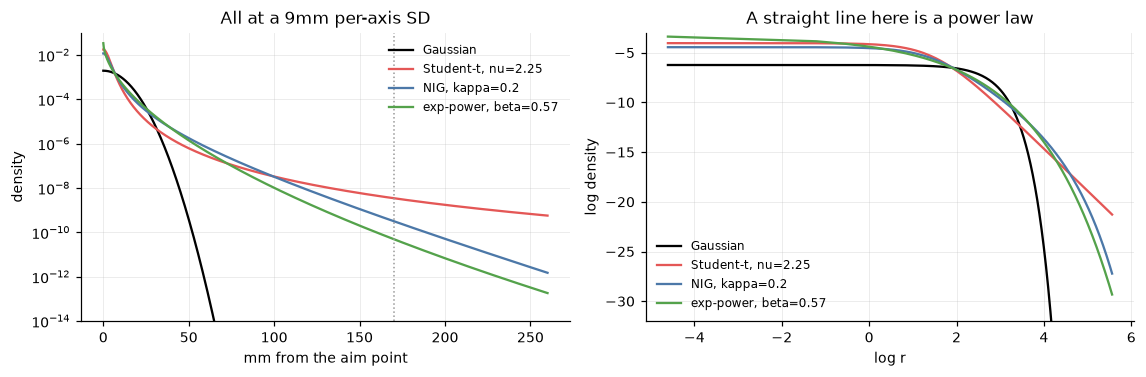

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.5))
r = np.linspace(0.01, 260, 900)
gauss = FAMILIES['gaussian']
sd = 9.0
curves = [('Gaussian', gauss, np.array([]), 'k'),
          ('Student-t, nu=2.25', FAMILIES['student-t'], np.array([np.log(0.25)]), '#e45756'),
          ('NIG, kappa=0.2', nig, np.array([np.log(0.2)]), '#4c78a8'),
          ('exp-power, beta=0.57', FAMILIES['exp-power'], np.array([np.log(0.57)]), '#54a24b')]
for label, fam, shape, col in curves:
    # put every family at the same per-axis SD so the tails are comparable
    s = sd
    for _ in range(60):
        s *= sd / fam.axis_sd(s, shape)
    d = fam.profile(r ** 2, s, shape) / fam.norm(s, shape)
    ax[0].semilogy(r, d, color=col, lw=1.5, label=label)
    ax[1].plot(np.log(r), np.log(np.maximum(d, 1e-300)), color=col, lw=1.5, label=label)
ax[0].axvline(170, color='0.6', ls=':', lw=1)
ax[0].set(xlabel='mm from the aim point', ylabel='density', ylim=(1e-14, 1e-1),
          title='All at a 9mm per-axis SD')
ax[0].legend(fontsize=8)
ax[1].set(xlabel='log r', ylabel='log density', ylim=(-32, -3),
          title='A straight line here is a power law')
ax[1].legend(fontsize=8)
fig.tight_layout()

The closed form agrees with the mixture integral it was derived from to **8e-14**
across `κ` from 0.05 to 100, the normaliser `2π σ²/κ` is exact rather than close,
and the scale really is the per-axis standard deviation to eight decimal places
whatever the tail is doing.

The right-hand panel is the reason to expect this family to compete. On log-log
axes a power law is a **straight line**, and the Student-t is one. The NIG bends
away and falls off a cliff; so does the exponential-power family, further out.
Both are heavy compared with a Gaussian and neither is polynomial.

That picture is the whole hypothesis in one image: if what real darts need is
*heavy* tails, the NIG has them and has every moment besides. If what they need is
specifically *polynomial* tails, only the t will do.

## 3 · The comparison, on the same held-out legs

Both new families go through the same harness as the original six: the same
players, the same whole-leg split, the same aim rule from notebook 20, the same
`--models` flag that adds a candidate without refitting the rest.

In [7]:
piv = FITS.pivot_table(index='player', columns='model', values='test_ll_per_visit')
n_test = FITS[FITS.model == 'student-t'].set_index('player').n_test
summary = (FITS.groupby('model')
           .agg(test_ll=('test_ll_per_visit', 'mean'),
                n_params=('n_params', 'first'))
           .sort_values('test_ll', ascending=False))
summary['vs_gaussian'] = summary.test_ll - summary.loc['gaussian', 'test_ll']
summary['new'] = ['<--' if m in ('elliptical-t', 'nig') else '' for m in summary.index]
print('held-out log-likelihood per visit, 17 players:')
print(summary.round(4).to_string())

print('\nhead-to-head, with a sign test over the seventeen players:')
for a, b in (('elliptical-t', 'student-t'), ('nig', 'student-t'),
             ('nig', 'exp-power'), ('nig', 'gaussian'), ('student-t', 'gaussian')):
    d = piv[a] - piv[b]
    print(f'   {a:<13} vs {b:<11} wins {int((d > 0).sum()):2d}/17   '
          f'median {d.median():+.4f}/visit   total {float((d * n_test).sum()):+9.1f} '
          f'log units   sign p = {stats.binomtest(int((d > 0).sum()), len(d), 0.5).pvalue:.4f}')

held-out log-likelihood per visit, 17 players:
                         test_ll  n_params  vs_gaussian  new
model                                                       
elliptical-t             -4.1139         6       0.6288  <--
student-t + visit scale  -4.1164         6       0.6264     
student-t                -4.1183         5       0.6244     
two-component            -4.1355         6       0.6073     
nig                      -4.1398         5       0.6029  <--
exp-power                -4.1595         5       0.5833     
gaussian + visit scale   -4.2283         5       0.5144     
core+uniform             -4.3198         5       0.4229     
gaussian                 -4.7427         4       0.0000     
elliptical               -4.7640         5      -0.0213     

head-to-head, with a sign test over the seventeen players:
   elliptical-t  vs student-t   wins 11/17   median +0.0023/visit   total     +21.2 log units   sign p = 0.3323
   nig           vs student-t   wins  2/17   medi

Two answers, and neither is the one the replies were built to produce.

**The elliptical t tops the table and it means nothing.** It has the best held-out
score of any model here, but the margin over the plain Student-t is
**+0.0023 a visit** -- 21 log-likelihood units spread over 5,469 held-out visits
and seventeen players, winning for 11 of them and losing for 6, sign test
`p = 0.33`. Held-out likelihood already charges for the extra parameter, so no
information criterion is needed to discount this: it is simply not distinguishable
from zero.

Which means **notebook 21's null survives its own objection**. A Gaussian core
does mismeasure elongation, exactly as section 1 showed -- and correcting that
still finds no elongation to measure.

**The NIG loses, decisively.** Two wins out of seventeen, `p = 0.0023`, 133 log
units behind the t on the same parameter count. And it is not a bad family: it
beats the exponential-power family 16-17 and the Gaussian 17-17 by 3,730 log
units. It is comfortably the best **bounded-moment** candidate anyone here has
fitted. It just cannot reach where the t reaches.

In [8]:
e = FITS[FITS.model == 'elliptical-t'].set_index('player')
g = FITS[FITS.model == 'nig'].set_index('player')
detail = pd.DataFrame({
    't_nu': t.shape_nu, 'on_boundary': t.at_boundary,
    'ellT_ratio': e.shape_ratio, 'ellT_gain': piv['elliptical-t'] - piv['student-t'],
    'nig_kappa': g.shape_kappa, 'nig_gain': piv['nig'] - piv['student-t'],
}).sort_values('t_nu').round(3)
print(detail.to_string())
print()
print('elongation: median ratio %.3f, range %.3f-%.3f, %d of 17 outside 0.9-1.1 '
      '-- and in both directions'
      % (detail.ellT_ratio.median(), detail.ellT_ratio.min(),
         detail.ellT_ratio.max(),
         int(((detail.ellT_ratio < 0.9) | (detail.ellT_ratio > 1.1)).sum())))
print('the boundary players are the ones the NIG was meant to rescue:')
print('   they lose %+.4f a visit under it;  everyone else loses %+.4f'
      % (detail[detail.on_boundary].nig_gain.mean(),
         detail[~detail.on_boundary].nig_gain.mean()))

                        t_nu  on_boundary  ellT_ratio  ellT_gain  nig_kappa  nig_gain
player                                                                               
Simon Whitlock         2.000         True       1.117      0.002      0.146    -0.040
Gary Anderson          2.001         True       0.889     -0.000      0.174    -0.026
Michael Smith          2.005         True       1.091      0.006      0.172    -0.022
Daryl Gurney           2.035         True       0.935      0.002      0.185    -0.015
Raymond van Barneveld  2.041         True       1.413      0.016      0.176    -0.040
Dave Chisnall          2.112        False       0.900      0.018      0.179     0.002
Peter Wright           2.132        False       0.938     -0.003      0.212    -0.031
Mensur Suljovic        2.226        False       1.578      0.042      0.202    -0.058
Gerwyn Price           2.245        False       0.877      0.010      0.255    -0.008
Jelle Klaasen          2.417        False       0.808 

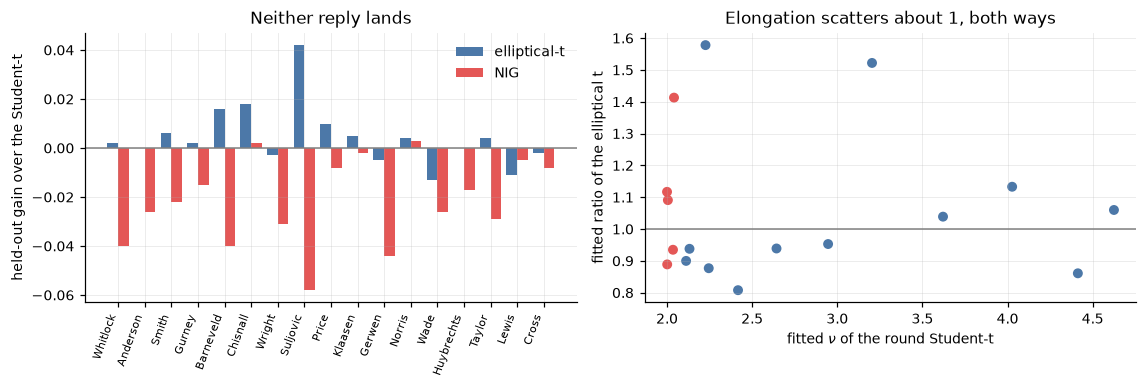

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
order = detail.index
x = np.arange(len(order))
ax[0].axhline(0, color='0.5', lw=1)
ax[0].bar(x - 0.2, detail.ellT_gain, 0.4, color='#4c78a8', label='elliptical-t')
ax[0].bar(x + 0.2, detail.nig_gain, 0.4, color='#e45756', label='NIG')
ax[0].set_xticks(x, [p.split()[-1] for p in order], rotation=70, ha='right', fontsize=7)
ax[0].set(ylabel='held-out gain over the Student-t', title='Neither reply lands')
ax[0].legend()

ax[1].axhline(1.0, color='0.5', lw=1)
ax[1].scatter(detail.t_nu, detail.ellT_ratio,
              c=np.where(detail.on_boundary, '#e45756', '#4c78a8'), s=30)
ax[1].set(xlabel=r'fitted $\nu$ of the round Student-t',
          ylabel='fitted ratio of the elliptical t',
          title='Elongation scatters about 1, both ways')
fig.tight_layout()

And the detail turns the NIG's defeat into something more useful than a defeat.

**The five boundary players lose *more* under it than everyone else** -- −0.029 a
visit against −0.019. The family was designed for them: no `ν = 2` fence to press
against, and a core that need not be tied to the tail. They are the players it
serves worst.

So the second reading in section 0 is wrong, and the first one is right in a way
that rules out the fix. Those five are not sitting on the boundary because the
parameterisation is awkward. They are sitting on it because their tails really are
heavier than *any* exponential, and a family with all its moments finite takes
away the thing they needed most. `ν → 2` is the data talking, not the code.

**The elongation scatters about 1 in both directions**: median 0.953, range 0.808
to 1.578, nine of seventeen outside 0.9–1.1 but with no shared sign. A real
systematic shape -- players' groups being taller than they are wide, say -- would
show up as a consistent direction across players. This is what noise looks like on
a parameter that has nothing to explain.

One limit on that, in fairness. The ellipse here is fixed to the *board's* axes,
radial and tangential at the treble 20, which is the convention notebook 21 set.
A group tilted at 30° to those axes would be partly invisible to both models. What
has been ruled out is elongation along the board's axes, not elongation.

## Conclusion

Two objections to notebook 21, both tested, both answered against the objection --
which leaves the Student-t better supported than it was, because two specific ways
it could have been wrong now have measurements attached.

**The ellipse.** The objection was correct in its premise and wrong in its
conclusion. A Gaussian core genuinely cannot measure elongation next to a heavy
tail: it reads a round heavy-tailed group as 1.15:1 and a real 1.60:1 group as
2.27:1. Notebook 21's null was measured with that instrument. Re-measured with a
Student-t core, which recovers 1.008 and 1.580 on the same simulations, the answer
does not move: **+0.0023 a visit, 11 wins from 17, `p = 0.33`.** There is no
ellipse on the board's axes to find.

**The boundary.** Five of seventeen players sit on `ν = 2`, and the natural reply
is a family that is heavy-tailed with every moment finite. The normal-inverse-
Gaussian is the right such family -- a Gaussian scale mixture like the t, so it
reuses the same machinery; exponential rather than polynomial tails, so nothing
diverges; and its scale is exactly the per-axis standard deviation, which not even
the t can claim. It beats every other bounded-moment candidate and the Gaussian by
3,730 log units. **It still loses to the t by 133, and it loses hardest on the
five players it was built for.**

That is the useful finding, and it is a stronger statement than "the t wins
again". The `ν = 2` boundary is not an artefact to be engineered around. Real
darts want a tail that is *polynomial*, not merely heavy -- heavy enough that
the variance may genuinely not exist, and no amount of reparameterising will make
that go away. Every result in notebooks 22 and 23 that treats `σ` as a core scale
rather than a spread was reading the situation correctly.

**What is still not tested.** The ellipse is pinned to the board's axes, so a
tilted group would be missed by both models. All seventeen players are
professionals, and everything remains bed-level -- no coordinates -- so what is
established is that a polynomial tail predicts *which bed* better than an
exponential one, not that a dart's landing point has been seen. And notebook 21's
sharpest open question is untouched here: a dart's width grows across the visit,
which no family on this list, all of them stationary within a visit, can produce.